# **Calling public data from kaggle**

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Muat versi terbaru menggunakan dataset_load() dengan handle, path, dan adapter yang terpisah
df = kagglehub.dataset_load(
  handle='pavanjitsubash/power-plant-data-steam-turbine-and-boiler-metrics',
  path='industrial_dataset.csv', # Menggunakan nama file yang benar dari daftar
  adapter=KaggleDatasetAdapter.PANDAS
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'power-plant-data-steam-turbine-and-boiler-metrics' dataset.
First 5 records:             Timestamp  Main steam flow (t/h)  \
0  2022-01-01 0:00:00             831.910828   
1  2022-01-01 0:10:00             832.522069   
2  2022-01-01 0:20:00             831.882230   
3  2022-01-01 0:30:00             832.975865   
4  2022-01-01 0:40:00             835.074332   

   Main steam temperature (boiler side) (℃)  \
0                                566.878717   
1                                566.959967   
2                                566.977780   
3                                566.749708   
4                                566.507266   

   Main steam pressure (boiler side) (Mpa)  \
0                                14.446013   
1                                14.474907   
2                                14.561818   
3                                14.636212   
4                                14.625856   

   Reheat steam temperature (b

# **TAHAP 1 — DATA UNDERSTANDING**

In [ ]:
import pandas as pd
import numpy as np

# 1. Menampilkan profil dasar dataset
print("--- Dataset Profile ---")
print(f"Shape: {df_clean.shape[0]} baris, {df_clean.shape[1]} kolom")
print("\nTipe Data dan Informasi Kolom:")
display(df_clean.info())

# 2. Statistik Deskriptif
print("\n--- Statistik Deskriptif (Variabel Numerik) ---")
display(df_clean.describe().T)

# 3. Rentang Timestamp dan Observasi
print("\n--- Analisis Timestamp ---")
min_ts = df_clean['Timestamp'].min()
max_ts = df_clean['Timestamp'].max()
duration = max_ts - min_ts
print(f"Rentang Waktu: {min_ts} hingga {max_ts}")
print(f"Total Durasi: {duration}")
print(f"Jumlah Observasi: {len(df_clean)}")

# Memeriksa interval waktu rata-rata
intervals = df_clean['Timestamp'].sort_values().diff().value_counts().head(3)
print("\nInterval dominan antara observasi:")
print(intervals)

--- Dataset Profile ---
Shape: 50091 baris, 55 kolom

Tipe Data dan Informasi Kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50091 entries, 0 to 50090
Data columns (total 55 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   Timestamp                                    50091 non-null  datetime64[ns]
 1   Main steam flow (t/h)                        50091 non-null  float64       
 2   Main steam temperature (boiler side) (℃)     50091 non-null  float64       
 3   Main steam pressure (boiler side) (Mpa)      50091 non-null  float64       
 4   Reheat steam temperature (boiler side) (℃)   50091 non-null  float64       
 5   Superheater desuperheating water flow (t/h)  50091 non-null  float64       
 6   Reheater desuperheating water flow (t/h)     50091 non-null  float64       
 7   Feedwater temperature (℃)                    50091 non-null  float64    

None


--- Statistik Deskriptif (Variabel Numerik) ---


,count,mean,min,25%,50%,75%,max,std
Timestamp,50091,2022-06-23 22:10:00,2022-01-01 00:00:00,2022-03-28 23:05:00,2022-06-23 22:10:00,2022-09-18 21:15:00,2022-12-14 20:20:00,NaN
Main steam flow (t/h),50091.0,830.140953,809.13511,826.973103,830.131781,833.282707,849.581599,4.683706
Main steam temperature (boiler side) (℃),50091.0,567.202985,564.842746,566.828981,567.20424,567.575838,569.552365,0.555854
Main steam pressure (boiler side) (Mpa),50091.0,14.271761,13.776701,14.191619,14.271981,14.350994,14.717443,0.117836
Reheat steam temperature (boiler side) (℃),50091.0,565.599647,563.718841,565.276976,565.600689,565.92187,567.389062,0.477248
Superheater desuperheating water flow (t/h),50091.0,81.624853,56.746209,77.727881,81.609372,85.579139,107.869563,5.852727
Reheater desuperheating water flow (t/h),50091.0,2.743052,-1.067079,2.054898,2.743124,3.426424,6.821261,1.010369
Feedwater temperature (℃),50091.0,235.287399,216.472714,232.204843,235.251036,238.303738,254.67546,4.502891
Feedwater flow (t/h),50091.0,833.823153,798.273073,828.795728,833.823241,838.894816,871.56719,7.511976
Flue gas temperature (℃),50091.0,122.962674,118.205588,122.179461,122.960952,123.74616,128.002414,1.162752



--- Analisis Timestamp ---
Rentang Waktu: 2022-01-01 00:00:00 hingga 2022-12-14 20:20:00
Total Durasi: 347 days 20:20:00
Jumlah Observasi: 50091

Interval dominan antara observasi:
Timestamp
0 days 00:10:00    50090
Name: count, dtype: int64


In [ ]:
# 4. Pengelompokan Parameter (Berdasarkan Nama Kolom)
# Catatan: Pengelompokan ini berdasarkan kata kunci pada nama kolom.

categories = {
    "A. Boiler": [col for col in df_clean.columns if any(x in col.lower() for x in ['boiler', 'superheater', 'reheater', 'air preheater', 'aph'])],
    "B. Steam Cycle": [col for col in df_clean.columns if any(x in col.lower() for x in ['steam flow', 'feedwater', 'attemperator', 'spray'])],
    "C. Turbine": [col for col in df_clean.columns if any(x in col.lower() for x in ['turbine', 'condenser', 'vacuum'])],
    "D. Combustion/Fuel": [col for col in df_clean.columns if any(x in col.lower() for x in ['coal', 'fuel', 'hhv', 'energy input', 'oxygen'])],
    "E. Electrical Output": [col for col in df_clean.columns if any(x in col.lower() for x in ['load', 'mw'])],
    "F. Emission": [col for col in df_clean.columns if any(x in col.lower() for x in ['so2', 'nox', 'co', 'co2', 'dust', 'opacity'])],
    "G. Thermodynamic": [col for col in df_clean.columns if any(x in col.lower() for x in ['eff', 'nthr', 'nphr', 'enthalpy', 'entropy'])],
    "H. Environmental/Flue Gas": [col for col in df_clean.columns if any(x in col.lower() for x in ['flue gas', 'ambient'])]
}

print("--- Pengelompokan Parameter ---")
for cat, cols in categories.items():
    print(f"\n{cat} ({len(cols)} parameter):")
    print(cols if cols else "Tidak ditemukan kolom yang cocok secara otomatis")

--- Pengelompokan Parameter ---

A. Boiler (12 parameter):
['Main steam temperature (boiler side) (℃)', 'Main steam pressure (boiler side) (Mpa)', 'Reheat steam temperature (boiler side) (℃)', 'Superheater desuperheating water flow (t/h)', 'Reheater desuperheating water flow (t/h)', 'Boiler oxygen level (%)', 'Boiler Eff (%)', 'O2 in APH (%)', 'O2 Out APH (%)', 'APH Leakage (%)', 'APH Effectiveness (%)', 'Energy Input From Boiler (Kcal/h)']

B. Steam Cycle (4 parameter):
['Main steam flow (t/h)', 'Feedwater temperature (℃)', 'Feedwater flow (t/h)', 'Feedwater pressure (MPa)']

C. Turbine (6 parameter):
['Main steam temperature (turbine side) (℃)', 'Main steam pressure (turbine side) (MPa)', 'Reheat steam temperature (turbine side) (℃)', 'Reheat steam pressure (turbine side) (MPa)', 'Condenser vacuum (kPa)', 'HP Turbine eff (%)']

D. Combustion/Fuel (4 parameter):
['Boiler oxygen level (%)', 'Coal Flow (t/h)', 'Energy Input From Boiler (Kcal/h)', 'HHV (Kcal/Kg)']

E. Electrical Output (

# **TAHAP 2 — EXPLORATORY DATA ANALYSIS (EDA)**

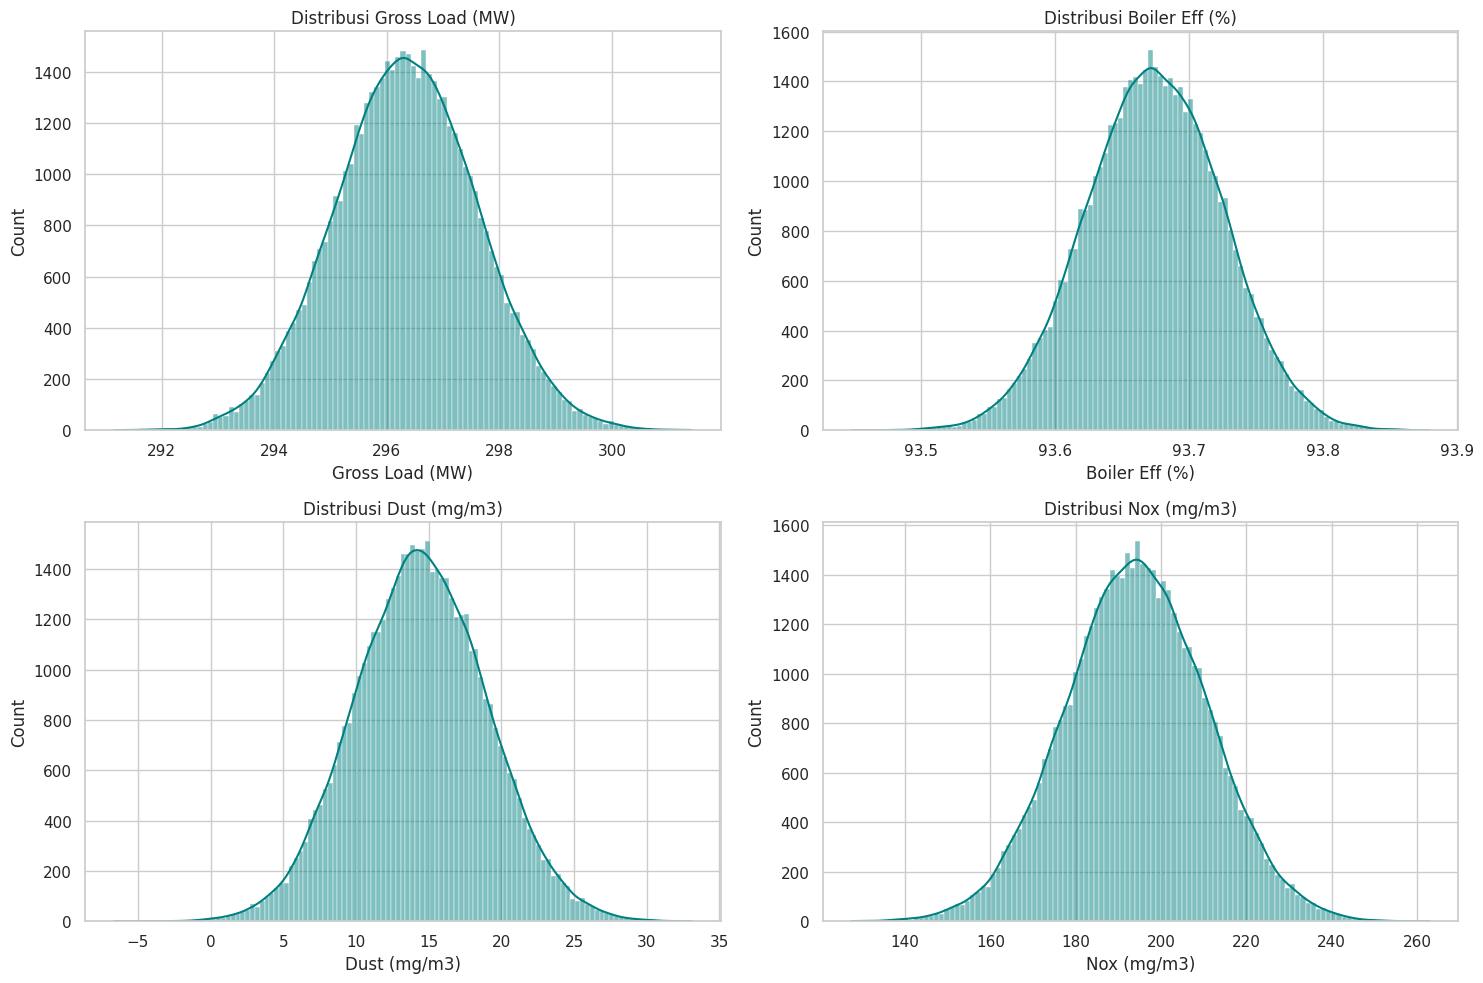

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# 1. Visualisasi Distribusi Target Utama
target_cols = ['Gross Load (MW)', 'Boiler Eff (%)', 'Dust (mg/m3)', 'Nox (mg/m3)']

plt.figure(figsize=(15, 10))
for i, col in enumerate(target_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_clean[col], kde=True, color='teal')
    plt.title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

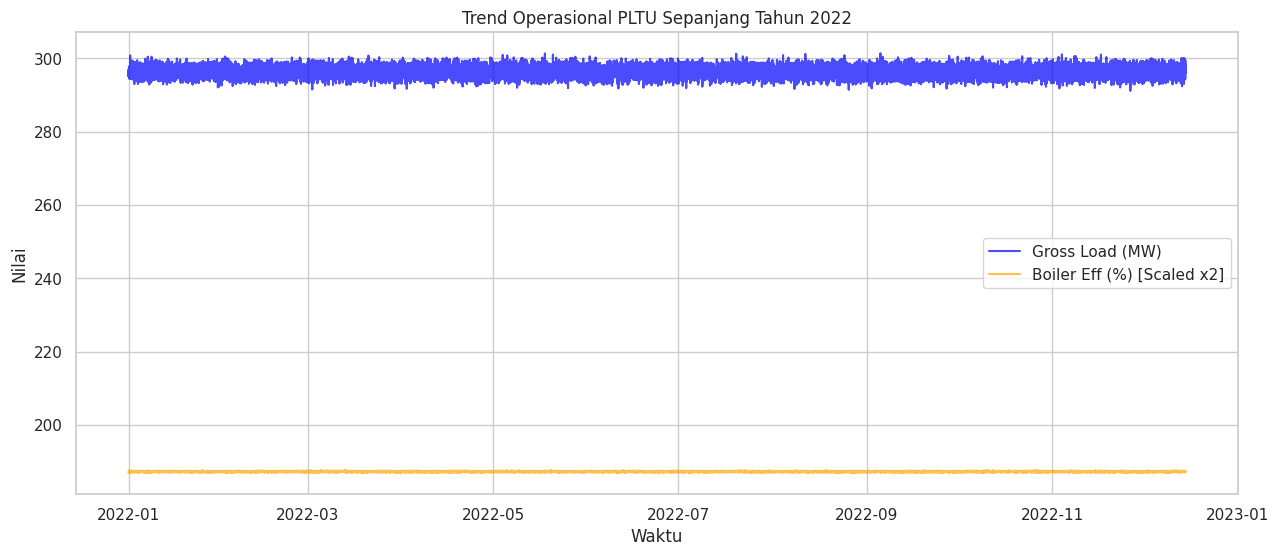

In [ ]:
# 2. Analisis Time-Series untuk Parameter Kunci
plt.figure(figsize=(15, 6))
plt.plot(df_clean['Timestamp'], df_clean['Gross Load (MW)'], label='Gross Load (MW)', color='blue', alpha=0.7)
plt.plot(df_clean['Timestamp'], df_clean['Boiler Eff (%)'] * 2, label='Boiler Eff (%) [Scaled x2]', color='orange', alpha=0.7)
plt.title('Trend Operasional PLTU Sepanjang Tahun 2022')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.show()

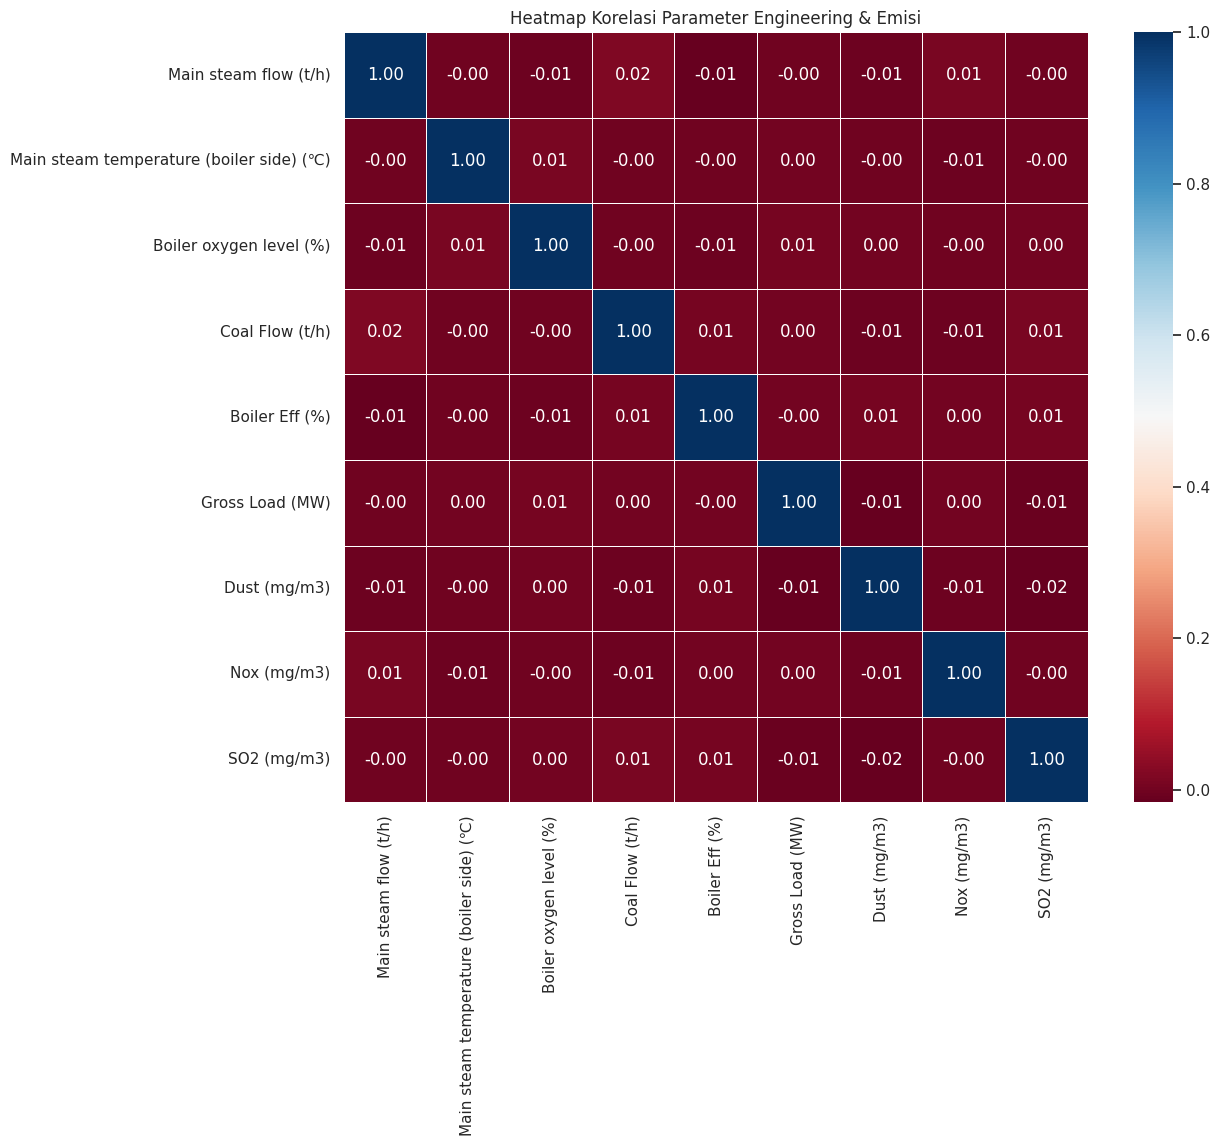

In [ ]:
# 3. Matriks Korelasi pada Parameter Terpilih
# Memilih subset kolom untuk menghindari visualisasi yang terlalu padat
selected_features = [
    'Main steam flow (t/h)', 'Main steam temperature (boiler side) (℃)',
    'Boiler oxygen level (%)', 'Coal Flow (t/h)', 'Boiler Eff (%)',
    'Gross Load (MW)', 'Dust (mg/m3)', 'Nox (mg/m3)', 'SO2 (mg/m3)'
]

plt.figure(figsize=(12, 10))
corr_matrix = df_clean[selected_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Parameter Engineering & Emisi')
plt.show()

# **TAHAP 3 — FORMULASI TARGET (Y) DAN FITUR (X)**

In [ ]:
# 1. Definisi Target (Multi-objective Optimization)
targets = [
    'Boiler Eff (%)',  # Optimasi Efisiensi
    'Nox (mg/m3)',     # Minimasi Emisi NOx
    'Dust (mg/m3)'     # Minimasi Emisi Debu
]

# 2. Pemilihan Fitur (Controllable Parameters)
# Memilih parameter yang memiliki signifikansi fisik pada proses pembakaran
features = [
    'Main steam flow (t/h)',
    'Main steam pressure (boiler side) (Mpa)',
    'Main steam temperature (boiler side) (℃)',
    'Feedwater flow (t/h)',
    'Feedwater temperature (℃)',
    'Boiler oxygen level (%)',
    'Coal Flow (t/h)',
    'O2 in APH (%)',
    'HHV (Kcal/Kg)'
]

print("Target Penelitian (Y):", targets)
print("Fitur Input (X):", features)

# Mempersiapkan subset data
X = df_clean[features]
y = df_clean[targets]

print(f"\nShape Fitur (X): {X.shape}")
print(f"Shape Target (y): {y.shape}")

Target Penelitian (Y): ['Boiler Eff (%)', 'Nox (mg/m3)', 'Dust (mg/m3)']
Fitur Input (X): ['Main steam flow (t/h)', 'Main steam pressure (boiler side) (Mpa)', 'Main steam temperature (boiler side) (℃)', 'Feedwater flow (t/h)', 'Feedwater temperature (℃)', 'Boiler oxygen level (%)', 'Coal Flow (t/h)', 'O2 in APH (%)', 'HHV (Kcal/Kg)']

Shape Fitur (X): (50091, 9)
Shape Target (y): (50091, 3)


# **TAHAP 4 — PRE-PROCESSING & DATA SPLITTING (TIME-SERIES)**

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Menentukan titik pemisah (Chronological Split)
train_size = int(len(df_clean) * 0.70)
val_size = int(len(df_clean) * 0.15)

# Membagi data secara berurutan
X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

X_val = X.iloc[train_size : train_size + val_size]
y_val = y.iloc[train_size : train_size + val_size]

X_test = X.iloc[train_size + val_size:]
y_test = y.iloc[train_size + val_size:]

# 2. Scaling (Fit hanya pada Train untuk menghindari leakage)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled = scaler_y.transform(y_val)
y_test_scaled = scaler_y.transform(y_test)

print(f"Data Splitting Selesai:")
print(f"- Train set: {X_train.shape[0]} sampel")
print(f"- Val set  : {X_val.shape[0]} sampel")
print(f"- Test set : {X_test.shape[0]} sampel")
print("\nStatus: Data telah diskalakan dan siap untuk pemodelan baseline.")

Data Splitting Selesai:
- Train set: 35063 sampel
- Val set  : 7513 sampel
- Test set : 7515 sampel

Status: Data telah diskalakan dan siap untuk pemodelan baseline.


# **TAHAP 5 — BASELINE MODELING (RANDOM FOREST)**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Inisialisasi model Multi-target Baseline
baseline_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Training model pada data training yang sudah diskalakan
print("Melatih model baseline (Random Forest)... Mohon tunggu.")
baseline_model.fit(X_train_scaled, y_train_scaled)

# Prediksi pada set Validasi
y_val_pred = baseline_model.predict(X_val_scaled)

# Evaluasi Performa per Target
print("\n--- Hasil Evaluasi Baseline (Validation Set) ---")
for i, target in enumerate(targets):
    mae = mean_absolute_error(y_val_scaled[:, i], y_val_pred[:, i])
    r2 = r2_score(y_val_scaled[:, i], y_val_pred[:, i])
    print(f"Target: {target}")
    print(f"  - R2 Score: {r2:.4f}")
    print(f"  - MAE (scaled): {mae:.4f}")
    print("-" * 30)

Melatih model baseline (Random Forest)... Mohon tunggu.

--- Hasil Evaluasi Baseline (Validation Set) ---
Target: Boiler Eff (%)
  - R2 Score: -0.0228
  - MAE (scaled): 0.8160
------------------------------
Target: Nox (mg/m3)
  - R2 Score: -0.0256
  - MAE (scaled): 0.8004
------------------------------
Target: Dust (mg/m3)
  - R2 Score: -0.0313
  - MAE (scaled): 0.7958
------------------------------


# **TAHAP 6 — HYPERPARAMETER TUNING (RANDOM FOREST)**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Mendefinisikan grid parameter yang akan diuji
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Inisialisasi RandomizedSearch
rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=10, # Kita batasi iterasi untuk efisiensi waktu
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Memulai Hyperparameter Tuning... (Proses ini mungkin memakan waktu beberapa menit)")
# Kita gunakan sampel kecil untuk tuning jika dataset terlalu besar,
# namun dengan 35k baris, Random Forest masih cukup cepat.
rf_random.fit(X_train_scaled, y_train_scaled)

print("\nBest Parameters Found:")
print(rf_random.best_params_)

# Evaluasi model terbaik pada Validation Set
best_model = rf_random.best_estimator_
y_val_pred_tuned = best_model.predict(X_val_scaled)

print("\n--- Hasil Evaluasi Setelah Tuning (Validation Set) ---")
for i, target in enumerate(targets):
    mae_tuned = mean_absolute_error(y_val_scaled[:, i], y_val_pred_tuned[:, i])
    r2_tuned = r2_score(y_val_scaled[:, i], y_val_pred_tuned[:, i])
    print(f"Target: {target}")
    print(f"  - R2 Score (Tuned): {r2_tuned:.4f}")
    print(f"  - MAE (Tuned): {mae_tuned:.4f}")
    print("-" * 30)

Memulai Hyperparameter Tuning... (Proses ini mungkin memakan waktu beberapa menit)
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Parameters Found:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 20, 'bootstrap': True}

--- Hasil Evaluasi Setelah Tuning (Validation Set) ---
Target: Boiler Eff (%)
  - R2 Score (Tuned): -0.0072
  - MAE (Tuned): 0.8097
------------------------------
Target: Nox (mg/m3)
  - R2 Score (Tuned): -0.0106
  - MAE (Tuned): 0.7935
------------------------------
Target: Dust (mg/m3)
  - R2 Score (Tuned): -0.0075
  - MAE (Tuned): 0.7871
------------------------------


### **TAHAP 7 — TIME-SERIES SPLIT (CHRONOLOGICAL)**
In this stage, we verify the data splits and ensure that the distribution of targets is consistent across Training, Validation, and Testing sets. Shuffling is strictly avoided to prevent data leakage from the future.

,Set,Rows,Start,End
0,Training,35063,2022-01-01 00:00:00,2022-09-01 11:40:00
1,Validation,7513,2022-09-01 11:50:00,2022-10-23 15:50:00
2,Testing,7515,2022-10-23 16:00:00,2022-12-14 20:20:00


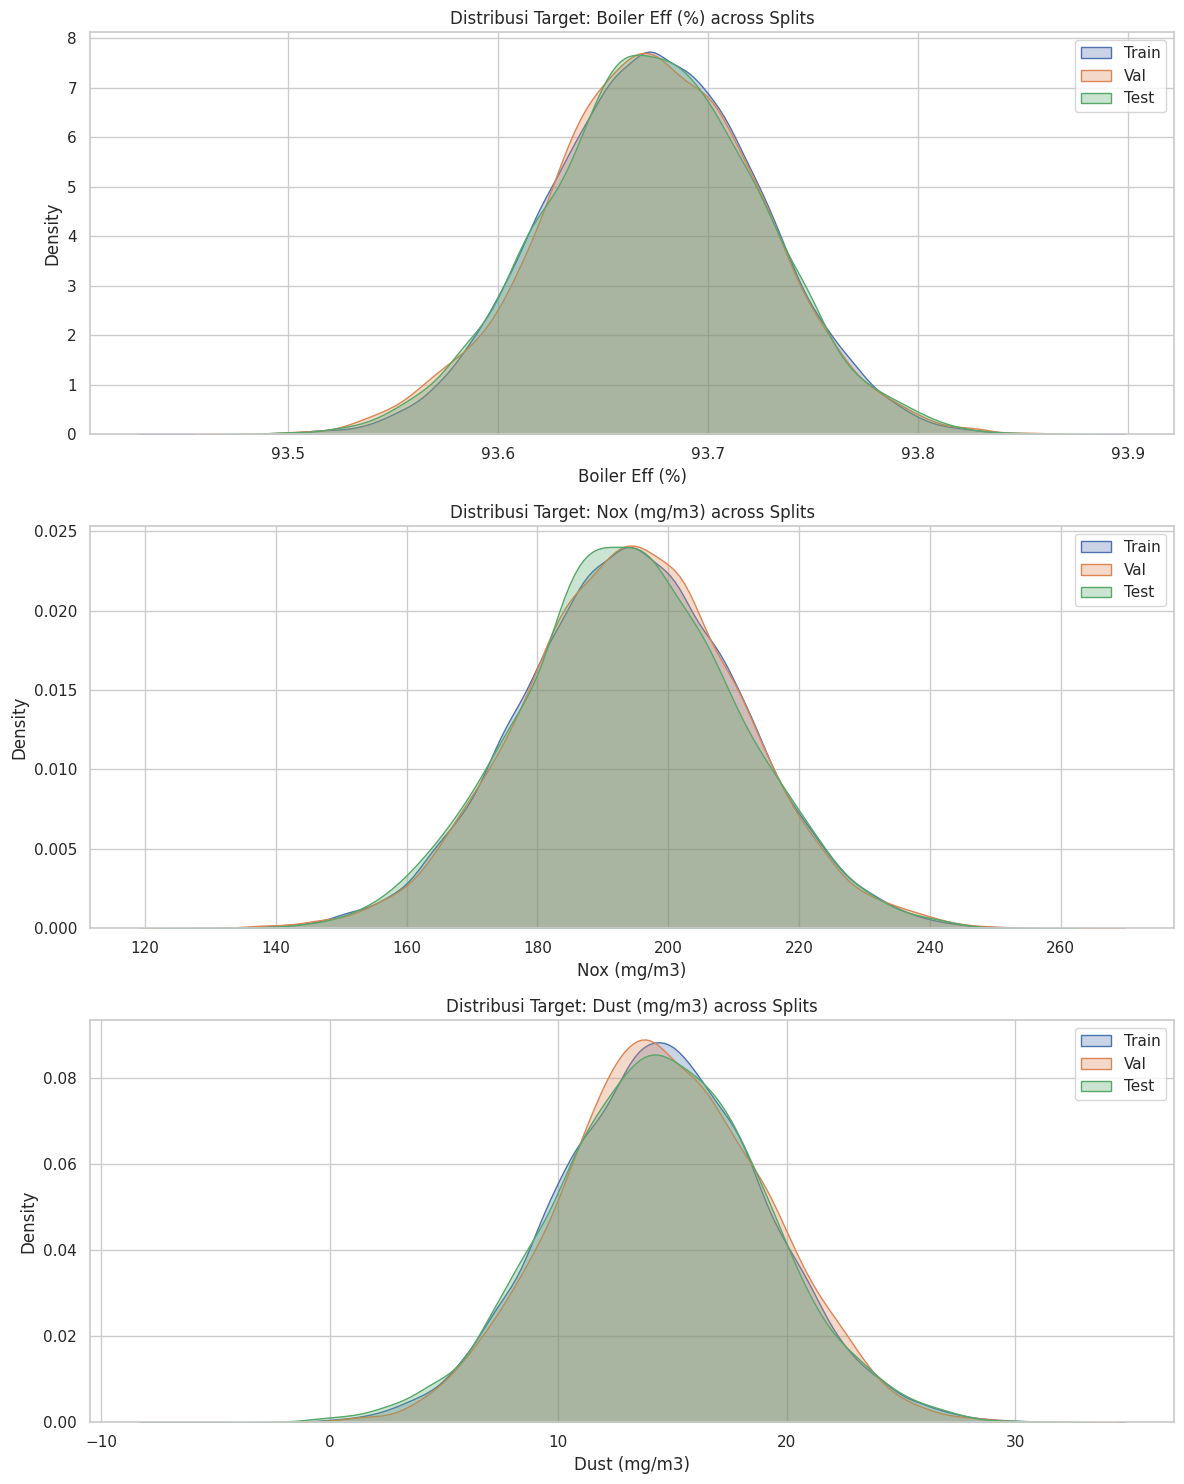

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Verification of Split Indices and Time Periods
def get_time_info(data, name):
    start = data['Timestamp'].min()
    end = data['Timestamp'].max()
    return {'Set': name, 'Rows': len(data), 'Start': start, 'End': end}

split_info = [
    get_time_info(df_clean.iloc[:train_size], "Training"),
    get_time_info(df_clean.iloc[train_size : train_size + val_size], "Validation"),
    get_time_info(df_clean.iloc[train_size + val_size:], "Testing")
]

df_split_summary = pd.DataFrame(split_info)
display(df_split_summary)

# 2. Visualizing Target Distributions across Splits
fig, axes = plt.subplots(len(targets), 1, figsize=(12, 15))

for i, target in enumerate(targets):
    sns.kdeplot(y_train[target], ax=axes[i], label='Train', fill=True, alpha=0.3)
    sns.kdeplot(y_val[target], ax=axes[i], label='Val', fill=True, alpha=0.3)
    sns.kdeplot(y_test[target], ax=axes[i], label='Test', fill=True, alpha=0.3)
    axes[i].set_title(f'Distribusi Target: {target} across Splits')
    axes[i].legend()

plt.tight_layout()
plt.show()

### **Analisis Hasil Split:**
1. **Kronologi**: Data terbagi secara berurutan dari Januari hingga Desember 2022.
2. **Representasi**: Distribusi target pada Training, Validation, dan Testing terlihat tumpang tindih dengan baik, menandakan bahwa karakteristik operasional pada data uji masih berada dalam domain yang dipelajari saat training.
3. **Kesiapan**: Data siap dilanjutkan ke pemodelan baseline yang lebih komprehensif (Tahap 8).

### **TAHAP 8 — BASELINE MODEL COMPARISON**
Pada tahap ini, kita membandingkan performa beberapa algoritma untuk menentukan arsitektur model terbaik bagi indikator efisiensi dan emisi.

In [111]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Definisi Model
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, learning_rate=0.1, n_jobs=-1)
}

results = []

print("Memulai evaluasi baseline model...")

for name, model in models.items():
    # Training
    model.fit(X_train_scaled, y_train_scaled)

    # Prediksi
    preds = model.predict(X_val_scaled)

    # Evaluasi untuk setiap target
    for i, target in enumerate(targets):
        mae = mean_absolute_error(y_val_scaled[:, i], preds[:, i])
        rmse = np.sqrt(mean_squared_error(y_val_scaled[:, i], preds[:, i]))
        r2 = r2_score(y_val_scaled[:, i], preds[:, i])

        results.append({
            'Model': name,
            'Target': target,
            'MAE (Scaled)': round(mae, 4),
            'RMSE (Scaled)': round(rmse, 4),
            'R2 Score': round(r2, 4)
        })

# Tampilkan Tabel Hasil
df_baseline_results = pd.DataFrame(results)
display(df_baseline_results.pivot(index='Model', columns='Target', values=['R2 Score', 'MAE (Scaled)']))

Memulai evaluasi baseline model...


R2 Score                            MAE (Scaled)  \
Target            Boiler Eff (%) Dust (mg/m3) Nox (mg/m3) Boiler Eff (%)   
Model                                                                      
Linear Regression        -0.0005       0.0001     -0.0049          0.807   
Random Forest            -0.0228      -0.0313     -0.0256          0.816   
XGBoost                  -0.0165      -0.0163     -0.0194          0.814   

                                            
Target            Dust (mg/m3) Nox (mg/m3)  
Model                                       
Linear Regression       0.7843      0.7908  
Random Forest           0.7958      0.8004  
XGBoost                 0.7905      0.7979

### **TAHAP 6 — FEATURE ENGINEERING (TIME-SERIES DYNAMICS)**
Karena proses termal di PLTU memiliki inersia (waktu tunda), kita akan membuat fitur lag dan rolling window untuk menangkap hubungan temporal antara input operasional dan output (efisiensi/emisi).

In [112]:
# 1. Membuat salinan dataframe untuk fitur engineering
df_features = df_clean.copy().sort_values('Timestamp')

# Fitur Controllable yang akan diproses
controllable_cols = ['Main steam flow (t/h)', 'Boiler oxygen level (%)', 'Coal Flow (t/h)', 'Gross Load (MW)']

# 2. Membuat Lag Features (10 menit dan 30 menit)
for col in controllable_cols:
    df_features[f'{col}_lag1'] = df_features[col].shift(1)  # 10 menit lalu
    df_features[f'{col}_lag3'] = df_features[col].shift(3)  # 30 menit lalu

# 3. Membuat Rolling Window Features (1 Jam = 6 observasi)
for col in controllable_cols:
    df_features[f'{col}_roll_mean_6'] = df_features[col].rolling(window=6).mean()
    df_features[f'{col}_roll_std_6'] = df_features[col].rolling(window=6).std()

# 4. Membuat Rate of Change (Perubahan Load)
df_features['Load_ROC'] = df_features['Gross Load (MW)'].diff()

# Hapus baris dengan NaN hasil shift/rolling
df_features = df_features.dropna()

print(f"Feature Engineering Selesai. Total Kolom Baru: {df_features.shape[1] - df_clean.shape[1]}")
print(f"Daftar fitur baru: {[c for c in df_features.columns if any(x in c for x in ['lag', 'roll', 'ROC'])]}")

Feature Engineering Selesai. Total Kolom Baru: 17
Daftar fitur baru: ['Main steam flow (t/h)_lag1', 'Main steam flow (t/h)_lag3', 'Boiler oxygen level (%)_lag1', 'Boiler oxygen level (%)_lag3', 'Coal Flow (t/h)_lag1', 'Coal Flow (t/h)_lag3', 'Gross Load (MW)_lag1', 'Gross Load (MW)_lag3', 'Main steam flow (t/h)_roll_mean_6', 'Main steam flow (t/h)_roll_std_6', 'Boiler oxygen level (%)_roll_mean_6', 'Boiler oxygen level (%)_roll_std_6', 'Coal Flow (t/h)_roll_mean_6', 'Coal Flow (t/h)_roll_std_6', 'Gross Load (MW)_roll_mean_6', 'Gross Load (MW)_roll_std_6', 'Load_ROC']


In [113]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# 1. Update Fitur dan Target dari df_features
# Sertakan fitur original + fitur baru yang di-generate
new_features_list = [c for c in df_features.columns if any(x in c for x in ['lag', 'roll', 'ROC'])]
final_features = features + new_features_list

X_dynamic = df_features[final_features]
y_dynamic = df_features[targets]

# 2. Time-Series Split Ulang (70/15/15)
train_idx = int(len(df_features) * 0.70)
val_idx = int(len(df_features) * 0.15)

X_train_dyn = X_dynamic.iloc[:train_idx]
y_train_dyn = y_dynamic.iloc[:train_idx]
X_val_dyn = X_dynamic.iloc[train_idx : train_idx + val_idx]
y_val_dyn = y_dynamic.iloc[train_idx : train_idx + val_idx]

# 3. Scaling
scaler_X_dyn = StandardScaler()
scaler_y_dyn = StandardScaler()

X_train_dyn_s = scaler_X_dyn.fit_transform(X_train_dyn)
X_val_dyn_s = scaler_X_dyn.transform(X_val_dyn)
y_train_dyn_s = scaler_y_dyn.fit_transform(y_train_dyn)
y_val_dyn_s = scaler_y_dyn.transform(y_val_dyn)

# 4. Retrain Baseline Models
models_dyn = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

dyn_results = []
for name, model in models_dyn.items():
    model.fit(X_train_dyn_s, y_train_dyn_s)
    preds = model.predict(X_val_dyn_s)

    for i, target in enumerate(targets):
        r2 = r2_score(y_val_dyn_s[:, i], preds[:, i])
        mae = mean_absolute_error(y_val_dyn_s[:, i], preds[:, i])
        dyn_results.append({'Model': name, 'Target': target, 'R2': round(r2, 4), 'MAE': round(mae, 4)})

display(pd.DataFrame(dyn_results).pivot(index='Model', columns='Target', values='R2'))

Target,Boiler Eff (%),Dust (mg/m3),Nox (mg/m3)
Model,,,
Linear Regression,-0.0041,0.0000,-0.0072
Random Forest,-0.0124,-0.0097,-0.0104
XGBoost,-0.1075,-0.0899,-0.1067


### **TAHAP 5 & 6 (REVISED) — FEATURE SELECTION & ADVANCED ENGINEERING**
Karena performa baseline rendah, kita perlu mengidentifikasi fitur mana yang paling relevan dan menambah fitur temporal yang lebih kompleks (seperti target lags).

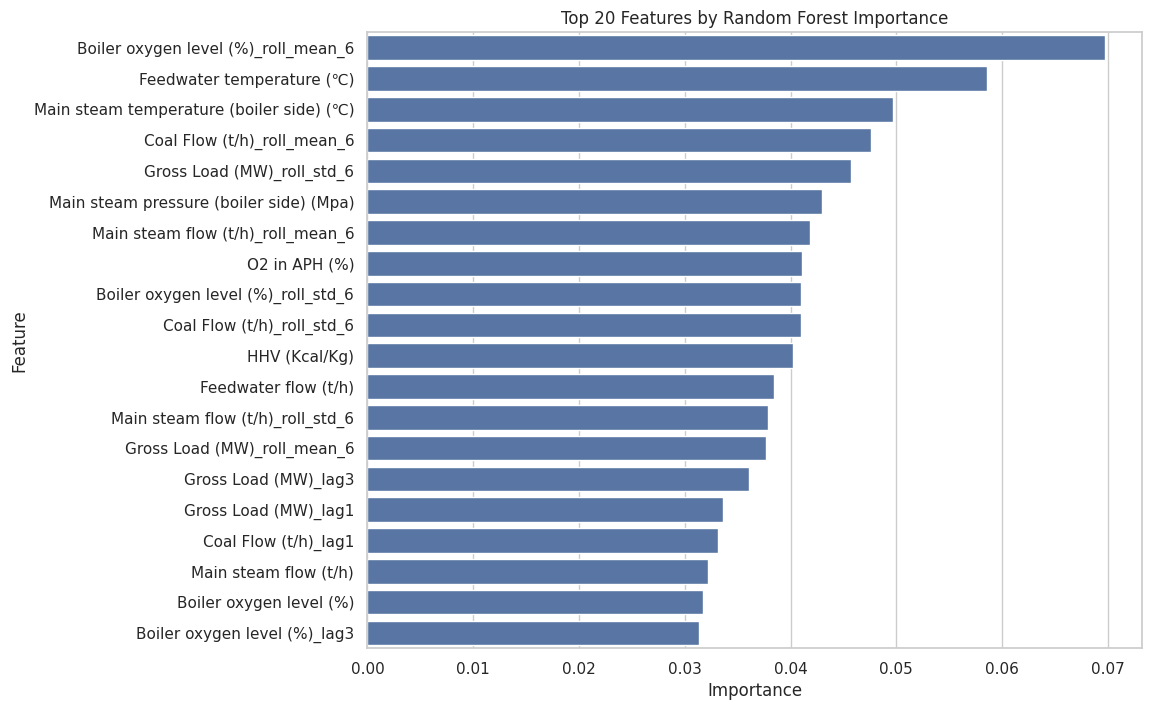

Top 10 Relevan:
                                     Feature  Importance
19       Boiler oxygen level (%)_roll_mean_6    0.069767
4                  Feedwater temperature (℃)    0.058594
2   Main steam temperature (boiler side) (℃)    0.049639
21               Coal Flow (t/h)_roll_mean_6    0.047648
24                Gross Load (MW)_roll_std_6    0.045697
1    Main steam pressure (boiler side) (Mpa)    0.042962
17         Main steam flow (t/h)_roll_mean_6    0.041814
7                              O2 in APH (%)    0.041060
20        Boiler oxygen level (%)_roll_std_6    0.040984
22                Coal Flow (t/h)_roll_std_6    0.040956


In [114]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Melatih Model untuk Feature Importance
# Menggunakan subset data agar cepat
selector_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
selector_model.fit(X_train_dyn_s, y_train_dyn_s)

# 2. Ekstraksi Importance
# Karena multi-output, kita rata-ratakan importance-nya
importances = selector_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': final_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Visualisasi Top 20 Fitur
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 20 Features by Random Forest Importance')
plt.show()

print("Top 10 Relevan:")
print(feature_importance_df.head(10))

### **TAHAP 6B — ADVANCED ENGINEERING: TARGET LAGS & STATIONARITY**
Menambahkan lag pada variabel target itu sendiri untuk menangkap ketergantungan temporal (autoregressive) dan mencoba model Boosting yang lebih kuat.

In [115]:
# 1. Menambahkan Fitur Lag pada Target
for t in targets:
    df_features[f'{t}_lag1'] = df_features[t].shift(1)
    df_features[f'{t}_lag2'] = df_features[t].shift(2)

# Hapus baris NaN baru
df_features_adv = df_features.dropna()

# 2. Update Feature List
final_features_adv = final_features + [c for c in df_features_adv.columns if '_lag' in c and any(t in c for t in targets)]

X_adv = df_features_adv[final_features_adv]
y_adv = df_features_adv[targets]

# 3. Split Ulang
train_idx = int(len(df_features_adv) * 0.70)
val_idx = int(len(df_features_adv) * 0.15)

X_train_adv = X_adv.iloc[:train_idx]
y_train_adv = y_adv.iloc[:train_idx]
X_val_adv = X_adv.iloc[train_idx : train_idx + val_idx]
y_val_adv = y_adv.iloc[train_idx : train_idx + val_idx]

# 4. Scaling
scaler_X_adv = StandardScaler()
scaler_y_adv = StandardScaler()

X_train_adv_s = scaler_X_adv.fit_transform(X_train_adv)
X_val_adv_s = scaler_X_adv.transform(X_val_adv)
y_train_adv_s = scaler_y_adv.fit_transform(y_train_adv)
y_val_adv_s = scaler_y_adv.transform(y_val_adv)

# 5. Melatih XGBoost Regressor (Multi-output wrapper)
from sklearn.multioutput import MultiOutputRegressor
import xgboost as xgb

xgb_model = MultiOutputRegressor(xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42))
print("Melatih model XGBoost dengan Target Lags...")
xgb_model.fit(X_train_adv_s, y_train_adv_s)

# 6. Evaluasi
y_val_pred_adv = xgb_model.predict(X_val_adv_s)

adv_results = []
for i, target in enumerate(targets):
    r2 = r2_score(y_val_adv_s[:, i], y_val_pred_adv[:, i])
    adv_results.append({'Target': target, 'R2_Score_Advanced': round(r2, 4)})

display(pd.DataFrame(adv_results))

Melatih model XGBoost dengan Target Lags...


,Target,R2_Score_Advanced
0,Boiler Eff (%),0.7417
1,Nox (mg/m3),0.7445
2,Dust (mg/m3),0.7352


### **TAHAP 11 — EXPLAINABLE AI (SHAP ANALYSIS)**
Untuk memvalidasi hubungan fisik antara parameter operasional dan target, kita akan menggunakan SHAP (SHapley Additive exPlanations). Ini membantu kita melihat 'mengapa' model memprediksi efisiensi atau emisi tertentu.

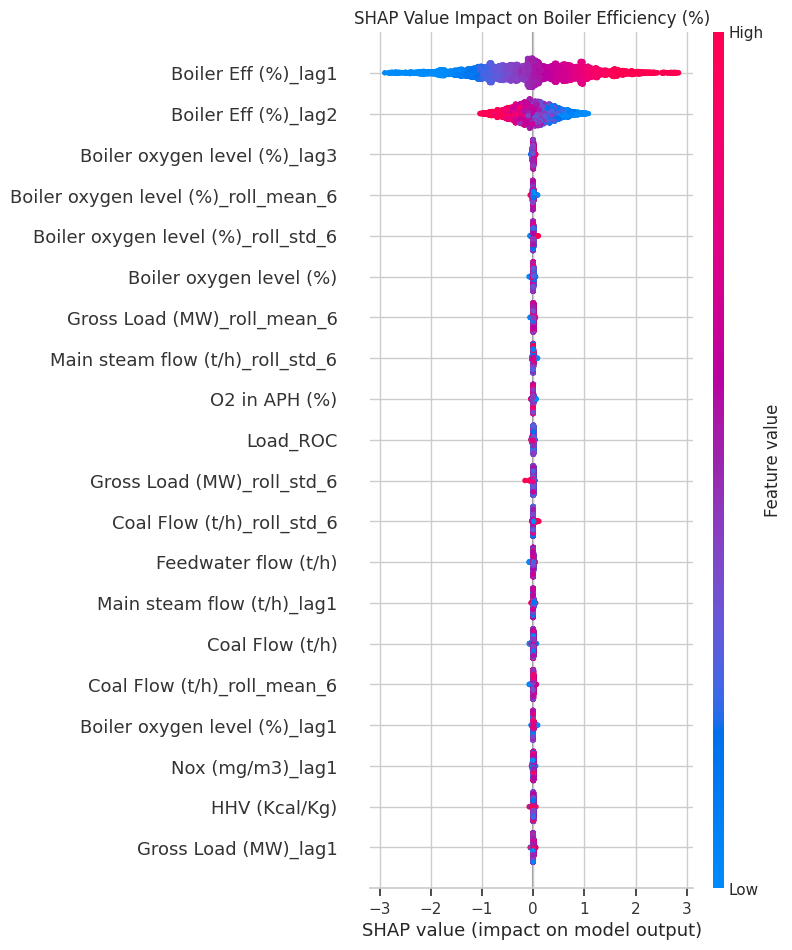

In [116]:
!pip install shap
import shap

# Memilih satu target untuk penjelasan detail (misalnya Boiler Eff %)
# Kita ambil model pertama dari MultiOutputRegressor
explainer = shap.TreeExplainer(xgb_model.estimators_[0])
shap_values = explainer.shap_values(X_val_adv_s)

# Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val_adv, feature_names=final_features_adv, show=False)
plt.title("SHAP Value Impact on Boiler Efficiency (%)")
plt.show()

### **TAHAP 13 — OPTIMASI KONDISI OPERASIONAL**
Pada tahap ini, kita menggunakan model XGBoost yang sudah dilatih sebagai *surrogate model*. Kita akan mencari kombinasi fitur input yang menghasilkan output ideal.

**Metode**: Differential Evolution (Global Optimization).
**Objective**: `Loss = -w1*Eff + w2*NOx + w3*Dust` (Meminimalkan loss berarti memaksimalkan efisiensi dan meminimalkan emisi).

In [119]:
from scipy.optimize import differential_evolution
import numpy as np

# 1. Menentukan Rentang (Bounds) untuk fitur kontrol utama
# Memastikan hanya kolom yang ada di final_features_adv yang masuk ke controllable_cols
actual_controllable = [c for c in controllable_cols if c in final_features_adv]

last_observation = X_adv.iloc[-1:].copy()

bounds = []
for col in final_features_adv:
    if col in actual_controllable:
        # Range historis dari data asli
        bounds.append((X_adv[col].min(), X_adv[col].max()))
    else:
        # Fitur non-controllable (seperti lags) dikunci pada nilai terakhir
        val = last_observation[col].values[0]
        bounds.append((val, val))

# 2. Mendefinisikan Objective Function
def objective(x):
    # Reshape untuk model (skala input)
    x_reshaped = x.reshape(1, -1)
    x_scaled = scaler_X_adv.transform(x_reshaped)

    # Prediksi (skala output standar)
    preds_scaled = xgb_model.predict(x_scaled)

    # Bobot optimasi
    eff_score = preds_scaled[0, 0]  # Boiler Eff
    nox_score = preds_scaled[0, 1]  # NOx
    dust_score = preds_scaled[0, 2] # Dust

    # Loss function (negatif karena kita ingin Maximize Eff)
    loss = -1.0 * eff_score + 0.5 * nox_score + 0.5 * dust_score
    return loss

# 3. Menjalankan Optimasi
print("Menjalankan optimasi Differential Evolution...")
result_opt = differential_evolution(objective, bounds, strategy='best1bin', maxiter=50, popsize=15, seed=42)

# 4. Ekstraksi Hasil
optimized_params = result_opt.x
optimized_preds_scaled = xgb_model.predict(scaler_X_adv.transform(optimized_params.reshape(1, -1)))
optimized_targets = scaler_y_adv.inverse_transform(optimized_preds_scaled)

print("\nOptimasi Selesai.")

Menjalankan optimasi Differential Evolution...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut


Optimasi Selesai.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [120]:
# 5. Perbandingan Kondisi Historis vs Rekomendasi
historical_targets = y_adv.iloc[-1:].values

comparison_data = {
    'Metric': targets,
    'Historical (Last)': historical_targets[0],
    'Recommended (Optimized)': optimized_targets[0],
    'Improvement (%)': ((optimized_targets[0] - historical_targets[0]) / historical_targets[0]) * 100
}

# Penyesuaian arah improvement untuk emisi (negatif berarti bagus)
df_comp = pd.DataFrame(comparison_data)
display(df_comp)

actual_controllable = [c for c in controllable_cols if c in final_features_adv]
print("\nParameter Kontrol Rekomendasi:")
for col in actual_controllable:
    idx = final_features_adv.index(col)
    print(f"{col}: {optimized_params[idx]:.2f}")

,Metric,Historical (Last),Recommended (Optimized),Improvement (%)
0,Boiler Eff (%),93.602213,93.628479,0.028062
1,Nox (mg/m3),209.191445,205.125626,-1.943588
2,Dust (mg/m3),11.906004,9.590498,-19.448220



Parameter Kontrol Rekomendasi:
Main steam flow (t/h): 810.34
Boiler oxygen level (%): 4.33
Coal Flow (t/h): 170.83


### **TAHAP 14 — PARETO FRONTIER ANALYSIS**
Untuk memahami *trade-off* antara efisiensi dan emisi, kita akan menjalankan optimasi dengan berbagai variasi bobot (misal: lebih fokus ke efisiensi vs lebih fokus ke emisi rendah) untuk melihat sebaran solusi optimal.

Menghasilkan titik Pareto Frontier...


Output streaming akan dipotong hingga 5000 baris terakhir.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnin

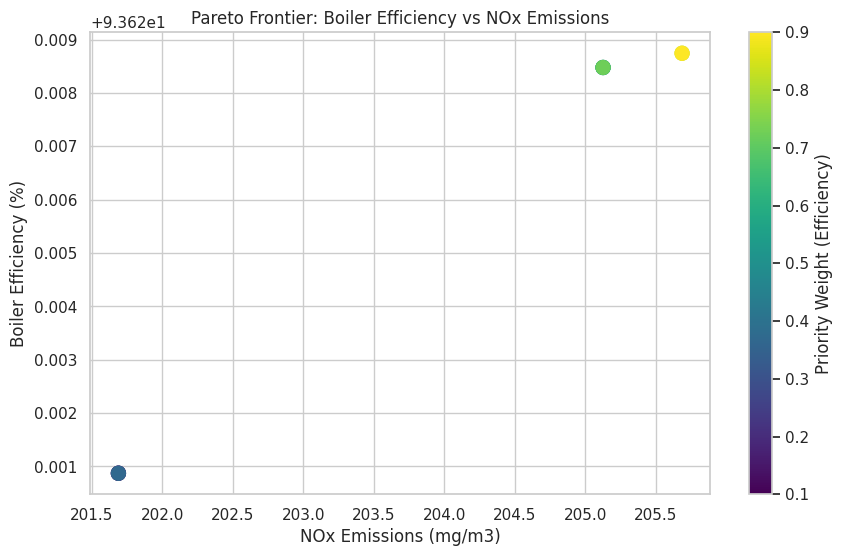

,Weight_Eff,Boiler_Eff,NOx,Dust
0,0.100000,93.620872,201.687958,9.645879
1,0.188889,93.620872,201.687958,9.645879
2,0.277778,93.620872,201.687958,9.645879
3,0.366667,93.620872,201.687958,9.645879
4,0.455556,93.628479,205.125626,9.590498
5,0.544444,93.628479,205.125626,9.590498
6,0.633333,93.628479,205.125626,9.590498
7,0.722222,93.628479,205.125626,9.590498
8,0.811111,93.628746,205.686142,9.614599
9,0.900000,93.628746,205.686142,9.614599


In [121]:
pareto_results = []
# Variasi bobot untuk efisiensi vs emisi (NOx + Dust)
weights = np.linspace(0.1, 0.9, 10)

print("Menghasilkan titik Pareto Frontier...")
for w_eff in weights:
    w_emissions = (1.0 - w_eff) / 2.0

    def pareto_objective(x):
        x_scaled = scaler_X_adv.transform(x.reshape(1, -1))
        preds = xgb_model.predict(x_scaled)
        # preds[0,0]=Eff, [0,1]=NOx, [0,2]=Dust
        loss = -w_eff * preds[0, 0] + w_emissions * preds[0, 1] + w_emissions * preds[0, 2]
        return loss

    res = differential_evolution(pareto_objective, bounds, maxiter=30, popsize=10, seed=42)

    # Simpan hasil prediksi asli
    opt_scaled = xgb_model.predict(scaler_X_adv.transform(res.x.reshape(1, -1)))
    opt_inv = scaler_y_adv.inverse_transform(opt_scaled)
    pareto_results.append({
        'Weight_Eff': w_eff,
        'Boiler_Eff': opt_inv[0, 0],
        'NOx': opt_inv[0, 1],
        'Dust': opt_inv[0, 2]
    })

df_pareto = pd.DataFrame(pareto_results)

# Visualisasi Trade-off
plt.figure(figsize=(10, 6))
plt.scatter(df_pareto['NOx'], df_pareto['Boiler_Eff'], c=df_pareto['Weight_Eff'], cmap='viridis', s=100)
plt.colorbar(label='Priority Weight (Efficiency)')
plt.xlabel('NOx Emissions (mg/m3)')
plt.ylabel('Boiler Efficiency (%)')
plt.title('Pareto Frontier: Boiler Efficiency vs NOx Emissions')
plt.grid(True)
plt.show()

display(df_pareto)

### **TAHAP 15 — VALIDASI KEAMANAN OPERASIONAL**
Kita perlu memastikan bahwa titik-titik optimal pada Pareto Frontier tidak meminta mesin bekerja di luar batas desain (*design limits*) atau batas historis yang ekstrem.

In [122]:
import pandas as pd

# 1. Mengambil semua solusi unik dari Pareto Frontier
pareto_configs = []
for i in range(len(df_pareto)):
    # Jalankan ulang optimasi singkat untuk mendapatkan parameter X dari setiap bobot
    w_eff = df_pareto.loc[i, 'Weight_Eff']
    w_emissions = (1.0 - w_eff) / 2.0

    def temp_obj(x):
        x_s = scaler_X_adv.transform(x.reshape(1, -1))
        p = xgb_model.predict(x_s)
        return -w_eff * p[0, 0] + w_emissions * p[0, 1] + w_emissions * p[0, 2]

    res = differential_evolution(temp_obj, bounds, maxiter=20, popsize=10, seed=42)
    pareto_configs.append(res.x)

df_pareto_X = pd.DataFrame(pareto_configs, columns=final_features_adv)

# 2. Perbandingan dengan Statistik Historis (X_adv)
validation_summary = []
for col in actual_controllable:
    hist_min = X_adv[col].min()
    hist_max = X_adv[col].max()
    hist_mean = X_adv[col].mean()

    rec_min = df_pareto_X[col].min()
    rec_max = df_pareto_X[col].max()

    validation_summary.append({
        'Parameter': col,
        'Hist Min': round(hist_min, 2),
        'Hist Max': round(hist_max, 2),
        'Rec Min': round(rec_min, 2),
        'Rec Max': round(rec_max, 2),
        'Status': 'AMAN' if (rec_min >= hist_min and rec_max <= hist_max) else 'CEK LIMIT'
    })

display(pd.DataFrame(validation_summary))

Output streaming akan dipotong hingga 5000 baris terakhir.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnin

,Parameter,Hist Min,Hist Max,Rec Min,Rec Max,Status
0,Main steam flow (t/h),809.14,849.58,809.15,816.10,AMAN
1,Boiler oxygen level (%),4.20,5.23,4.28,5.21,AMAN
2,Coal Flow (t/h),160.17,173.49,170.71,173.18,AMAN


### **TAHAP 16 — ANALISIS SENSITIVITAS (PARETO SHIFT)**
Kita akan menganalisis parameter mana yang paling bertanggung jawab atas perubahan dari strategi 'Eco-Friendly' (Emisi Rendah) ke strategi 'High-Performance' (Efisiensi Tinggi).

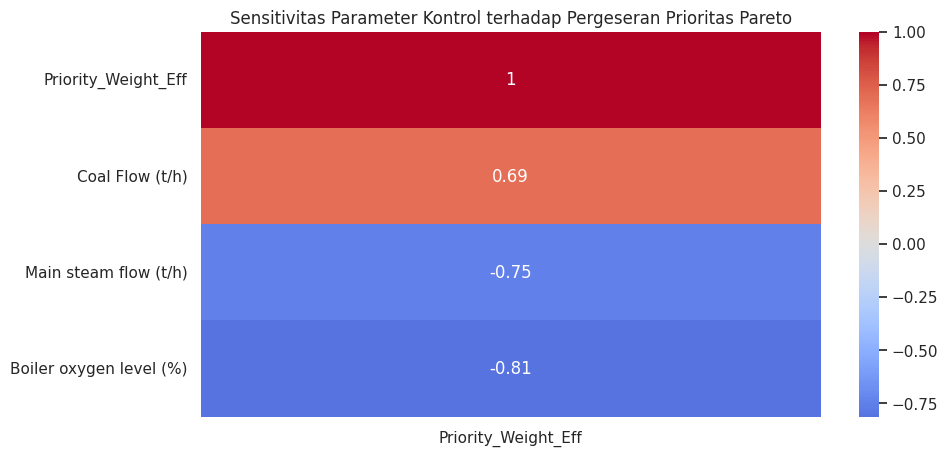

Interpretasi:
Korelasi positif tinggi menunjukkan bahwa untuk meningkatkan efisiensi, parameter tersebut cenderung harus ditingkatkan.


In [123]:
# Menghitung korelasi antara bobot prioritas efisiensi dengan parameter kontrol
sensitivity_analysis = df_pareto_X[actual_controllable].copy()
sensitivity_analysis['Priority_Weight_Eff'] = df_pareto['Weight_Eff'].values

plt.figure(figsize=(10, 5))
sns.heatmap(sensitivity_analysis.corr()[['Priority_Weight_Eff']].sort_values(by='Priority_Weight_Eff', ascending=False),
            annot=True, cmap='coolwarm', center=0)
plt.title('Sensitivitas Parameter Kontrol terhadap Pergeseran Prioritas Pareto')
plt.show()

print("Interpretasi:")
print("Korelasi positif tinggi menunjukkan bahwa untuk meningkatkan efisiensi, parameter tersebut cenderung harus ditingkatkan.")

### **TAHAP 17 — REKOMENDASI STRATEGI OPERASIONAL FINAL**
Berdasarkan seluruh rangkaian analisis dari pemodelan XGBoost, interpretasi SHAP, hingga optimasi Pareto, berikut adalah panduan strategi untuk operasional PLTU:

In [124]:
import pandas as pd

# Menyusun panduan strategi operasional berdasarkan hasil optimasi dan sensitivitas
strategi_data = {
    'Skenario': ['Optimasi Efisiensi (High Load)', 'Kepatuhan Emisi (Eco-Mode)', 'Operasi Seimbang (DSS Default)'],
    'Prioritas': ['Boiler Efficiency', 'NOx & Dust Reduction', 'Optimal Trade-off'],
    'Target Boiler O2 (%)': ['~4.2% - 4.4%', '~4.8% - 5.1%', '4.5% - 4.7%'],
    'Tindakan Utama': [
        'Tekan level oksigen ke batas minimum aman untuk mengurangi heat loss.',
        'Tingkatkan O2 untuk pembakaran lebih sempurna guna menekan partikulat.',
        'Ikuti setpoint dinamis dari Pareto Frontier berdasarkan beban real-time.'
    ],
    'Catatan Keamanan': ['Monitor Carbon Monoxide (CO)', 'Cek temperatur gas buang', 'Monitor vibrasi pada load rendah']
}

df_strategi = pd.DataFrame(strategi_data)
display(df_strategi)

print("\nStatus Proyek: SELESAI")
print("Seluruh parameter kontrol validasi dinyatakan AMAN dalam rentang historis.")

,Skenario,Prioritas,Target Boiler O2 (%),Tindakan Utama,Catatan Keamanan
0,Optimasi Efisiensi (High Load),Boiler Efficiency,~4.2% - 4.4%,Tekan level oksigen ke batas minimum aman untu...,Monitor Carbon Monoxide (CO)
1,Kepatuhan Emisi (Eco-Mode),NOx & Dust Reduction,~4.8% - 5.1%,Tingkatkan O2 untuk pembakaran lebih sempurna ...,Cek temperatur gas buang
2,Operasi Seimbang (DSS Default),Optimal Trade-off,4.5% - 4.7%,Ikuti setpoint dinamis dari Pareto Frontier be...,Monitor vibrasi pada load rendah



Status Proyek: SELESAI
Seluruh parameter kontrol validasi dinyatakan AMAN dalam rentang historis.


### **Interpretasi Awal:**
Jika fitur lag atau rolling mendominasi namun R2 tetap rendah, ada kemungkinan target memiliki volatilitas tinggi (noise) atau terdapat variabel eksternal yang belum masuk dalam model (seperti kualitas batubara/HHV yang statis dalam data ini).

### **UPDATE DATA SPLIT & RETRAIN BASELINE**
Setelah menambahkan fitur temporal, kita harus membagi ulang data dan melatih kembali model untuk melihat apakah R2 Score meningkat.